In [175]:
import pandas as pd
import numpy as np
import itertools
import random
import polars as pl
import matplotlib.pyplot as plt

In [176]:
import itertools
import random
import numpy as np
import pandas as pd
import polars as pl

models = [
    "GPT-4", "GPT-4o", "GPT-3.5-Turbo", "Llama-3-70B", "Llama-3-8B",
    "Mistral-8B", "Mistral-7B", "Claude-3-Sonnet", "Claude-3-Haiku", "Claude-3-Opus",
    "Gemini-1.5-Pro", "Gemini-1.5-Flash", "Vicuna-13B", "Vicuna-7B", "Alpaca-7B",
    "Phi-3-Mini", "Phi-3-Medium", "Qwen-72B", "Qwen-14B", "StableLM-3B",
    "StableLM-7B", "Mistral-Nemo", "OpenChat-3.5", "OLMo-7B", "Yi-34B"
]

comparison_sets = ["LLM Family", "Car Brands", "Telcos", "Search Engines", "Banks"]

permutations = list(itertools.product(models, comparison_sets))
df = pd.DataFrame(permutations, columns=["model", "comparison_set"])

num_rows = len(df)
num_favouritism_indices = random.sample(range(num_rows), k=int(0.3 * num_rows))  # 30% favouritism
num_disfavouritism_indices = random.sample(range(num_rows), k=int(0.1 * num_rows))  # 10% disfavouritism

df["num_favouritism"] = 0
df.loc[num_favouritism_indices, "num_favouritism"] = np.random.randint(1, 6, size=len(num_favouritism_indices))  # 1-5

df["num_disfavouritism"] = 0
df.loc[num_disfavouritism_indices, "num_disfavouritism"] = np.random.randint(1, 4, size=len(num_disfavouritism_indices))  # 1-3

df["num_favouritism"] = df["num_favouritism"].astype('Int64')
df["num_disfavouritism"] = df["num_disfavouritism"].astype('Int64')

df = pl.from_dataframe(df)
print(df.to_pandas().to_string())

                model  comparison_set  num_favouritism  num_disfavouritism
0               GPT-4      LLM Family                0                   0
1               GPT-4      Car Brands                1                   0
2               GPT-4          Telcos                0                   0
3               GPT-4  Search Engines                0                   0
4               GPT-4           Banks                3                   0
5              GPT-4o      LLM Family                0                   0
6              GPT-4o      Car Brands                0                   2
7              GPT-4o          Telcos                0                   0
8              GPT-4o  Search Engines                0                   0
9              GPT-4o           Banks                0                   0
10      GPT-3.5-Turbo      LLM Family                1                   0
11      GPT-3.5-Turbo      Car Brands                0                   0
12      GPT-3.5-Turbo    

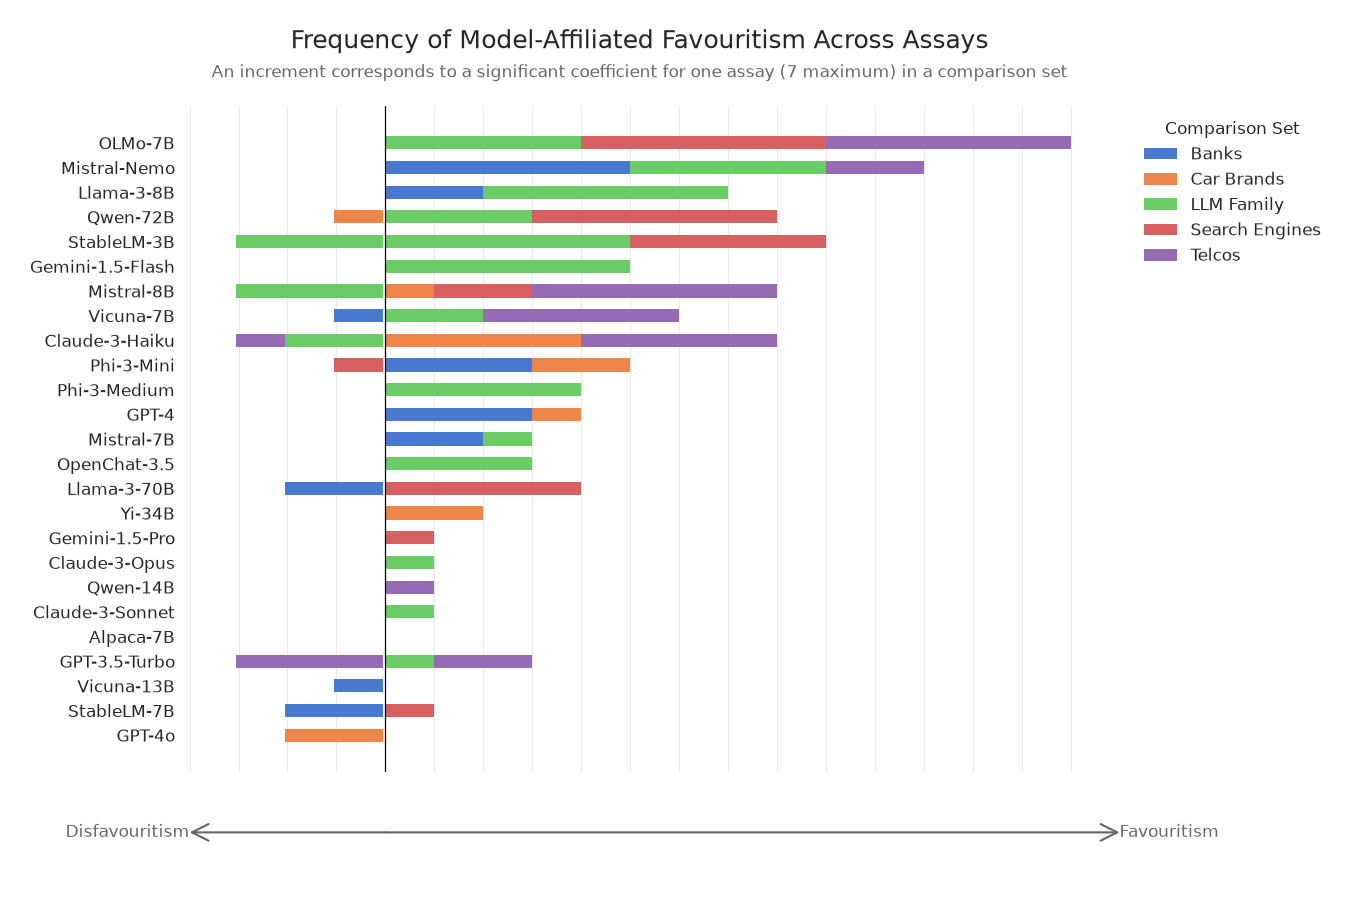

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pdf = df.to_pandas()
pivot_fav = pdf.pivot_table(index="model", columns="comparison_set", values="num_favouritism", fill_value=0)
pivot_dis = pdf.pivot_table(index="model", columns="comparison_set", values="num_disfavouritism", fill_value=0)

net_diff = (pivot_fav.sum(axis=1) - pivot_dis.sum(axis=1))
sorted_models = net_diff.sort_values(ascending=False).index

pivot_fav = pivot_fav.loc[sorted_models]
pivot_dis = pivot_dis.loc[sorted_models]

comparison_sets = sorted(pdf["comparison_set"].unique())
colors = sns.color_palette("muted", n_colors=len(comparison_sets))

plt.style.use("seaborn-v0_8-white")
fig, (ax, ax_arrow) = plt.subplots(2, 1, figsize=(4, 3.2), dpi=300,
                                   gridspec_kw={'height_ratios': [8, 1], 'hspace': 0.05})
plt.subplots_adjust(bottom=0.1, top=0.9)

y_pos = np.arange(len(pivot_fav)) * 1.5

bottom = np.zeros(len(pivot_fav))
for i, set_ in enumerate(comparison_sets):
    ax.barh(y_pos, pivot_fav[set_], left=bottom, color=colors[i], label=set_, edgecolor="none", height=0.8)
    bottom += pivot_fav[set_]

top = np.zeros(len(pivot_dis))
gap = 0.01 * max(pivot_fav.max().max(), pivot_dis.max().max())
for i, set_ in enumerate(comparison_sets):
    ax.barh(y_pos, -pivot_dis[set_], left=top - gap, color=colors[i], edgecolor="none", height=0.8)
    top -= pivot_dis[set_]

max_positive = bottom.max() + 1
max_negative = (-top).max() + 1

ax.set_xlim(-max_negative, max_positive)
x_ticks = np.arange(-int(max_negative), int(max_positive) + 1, 1)
ax.set_xticks(x_ticks)
ax.set_xticklabels([])

ax.grid(axis="x", color="0.9", linestyle="-", linewidth=0.2, which="both")
ax.axvline(0, color="black", linewidth=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(pivot_fav.index, fontsize=4)
ax.set_facecolor("none")

ax.legend(title="Comparison Set", title_fontsize=4, fontsize=4, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

# Title and subtitle
fig.suptitle("Frequency of Model-Affiliated Favouritism Across Assays", fontsize=6, y=0.98)
fig.text(0.5, 0.93, "An increment corresponds to a significant coefficient for one assay (7 maximum) in a comparison set",
         ha='center', fontsize=4, color='0.4')

# Arrows in the bottom subplot
ax_arrow.set_xlim(-max_negative, max_positive)
ax_arrow.set_ylim(0, 1)
ax_arrow.axis('off')

ax_arrow.annotate('',
                  xy=(max_positive, 0.5),
                  xytext=(0, 0.5),
                  arrowprops=dict(arrowstyle="->", color='0.4', lw=0.5, shrinkA=0, shrinkB=0))
ax_arrow.text(max_positive, 0.5, "Favouritism", ha='left', va='center', fontsize=4, color='0.4')

ax_arrow.annotate('',
                  xy=(-max_negative, 0.5),
                  xytext=(0, 0.5),
                  arrowprops=dict(arrowstyle="->", color='0.4', lw=0.5, shrinkA=0, shrinkB=0))
ax_arrow.text(-max_negative, 0.5, "Disfavouritism", ha='right', va='center', fontsize=4, color='0.4')

sns.despine(left=True, bottom=True, right=True, ax=ax)
ax.invert_yaxis()
plt.savefig("favoritism_plot.pdf", bbox_inches="tight", dpi=300, format="pdf")
plt.show()